# Token Predictor
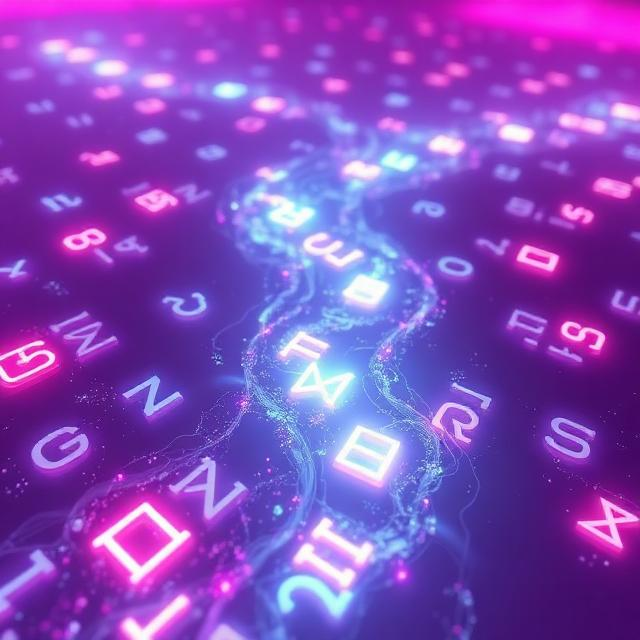

*Image generated using DeepAI.*

## Introduction

Large language models (LLMs), such as GPT-2, learn statistical relationships between tokens in text. At each step, the model processes a sequence of tokens and assigns a probability to every possible next token. This probability distribution reflects the model’s knowledge about which words and phrases naturally follow one another in a given context.

## Task

You are given a pre-trained GPT-2 XL model and a text dataset containing lines from various plays by William Shakespeare.
Your task is to build the best possible model which, based on a given text fragment (of size 512 tokens), can predict which tokens from a provided list will appear in the continuation of the text (within the next `q_size = 128` tokens).

## Data

The dataset consists of three parts:

1. A training dataset, which is a continuous fragment of text consisting of 301,966 tokens. The data comes from lines of various Shakespeare plays.

2. A validation dataset — 99 examples (constructed from a different fragment of the same text as the training set), where each example contains:

* `prompt` — a sequence of 512 context tokens.
* `good_tokens` — `q_size = 128` tokens that actually appear after the prompt in the original text.
* `bad_tokens` — `q_size = 128` tokens that do **not** appear in the next `q_size` tokens after the prompt (negative examples).
* `token_list` — contains exactly 256 tokens, where 128 are `good_tokens` and 128 are `bad_tokens`, shuffled in random order.

3. A test dataset — 100 examples that will be used to evaluate your solution. You do not have access to the test data while solving the task.

## Evaluation Criterion

Given `prompt` and `token_list`, your solution must distinguish `good_tokens` from `bad_tokens` and return `good_answer` and `bad_answer`, which represent the tokens predicted by the model as belonging to each group. Both lists should form a disjoint partition of `token_list`, meaning that every token from `token_list` must be assigned to exactly one of them.

The quality of your solution will be measured using **classification accuracy**:

$$
\text{score} = \frac{1}{2}*(\frac{|\text{set}(good\_tokens) \cap \text{set}(good\_answer)|}{|\text{set}(good\_tokens)|} + \frac{|\text{set}(bad\_tokens) \cap \text{set}(bad\_answer)|}{|\text{set}(bad\_tokens)|})
$$

You can receive between 0 and 100 points for this task. The score will be scaled linearly depending on the achieved **average accuracy** over the entire test set:

* **Accuracy ≤ 0.62**: 0 points
* **Accuracy ≥ 0.68**: 100 points
* **Values in between**: linearly scaled.

The final score is computed according to the formula:

$$
\text{Points} =
\begin{cases}
0 & \text{for } \text{Accuracy} \leq 0.62 \\
100 \times \frac{\text{Accuracy} - 0.62}{0.68 - 0.62} & \text{for } 0.62 < \text{Accuracy} < 0.68 \\
100 & \text{for } \text{Accuracy} \geq 0.68
\end{cases}
$$

## Constraints

* Your solution will be tested on the Competition Platform without internet access.
* Evaluation of your final solution must not exceed **5 minutes** (with GPU support).
* Allowed libraries: `numpy`, `pytorch`.

## Submission Files

This notebook completed with your solution (see the `YourSolution` class).

## Evaluation

Remember that during evaluation the `FINAL_EVALUATION_MODE` flag will be set to `True`.

You can receive between 0 and 100 points for this task. The number of points awarded will be calculated on the (hidden) test set on the Competition Platform according to the formula described above, rounded to the nearest integer. If your solution does not satisfy the above criteria or does not execute correctly, you will receive 0 points for the task.


# Starter Code

In this section, we initialize the environment by importing the required libraries and functions, and loading the GPT-2 model. The prepared code will help you efficiently work with the data and build the proper solution.


In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################
FINAL_EVALUATION_MODE = False # During evaluation on the grader, the flag is automatically set to True.

In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
import os
import random

# Setting the random seed to ensure deterministic results
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device      = 'cuda' if torch.cuda.is_available() else 'cpu'
block_size  = 1024
prompt_size = 512
q_size      = 128   # must be equal to WINDOW_LEN in AuthorsSolution
assert prompt_size + 3 * q_size <= block_size

print(f"Używane urządzenie: {device}")

## Model Definition

Below is the definition of the GPT-2 model used in the task. You may modify this code freely — for example, by adding new methods. As an example, we created the `model.query(prompt, token_list)` method, which returns logits based on the prompt — described below.


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=True)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=True)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head  = config.n_head
        self.n_embd  = config.n_embd
        self.dropout = config.dropout

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0, is_causal=True)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.c_proj(y))


class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        from types import SimpleNamespace
        config = SimpleNamespace(**config)
        config.dropout = 0.0
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        print("Number of model parameters: %.2fM" % (sum(p.numel() for p in self.parameters()) / 1e6,))

    def forward(self, idx):
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        return x @ self.transformer.wte.weight.mT

    def query(self, prompt, token_list):
        """
        For a given prompt and a list of tokens, returns a list of logits:

        Args:
            prompt     (torch.Tensor): 1D tensor of context tokens, shape [T].
            token_list (list[int]):    list of tokens to be classified.

        Returns:
            (list[int]): list of logits for the given tokens.
        """
        ctx = torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16) if device == 'cuda' else torch.amp.autocast(device_type='cpu', enabled=False)
        with torch.no_grad():
            with ctx:
                L = len(token_list)
                logits = self(prompt[None, ...])[0, -1, :]
                logits = logits.to(torch.float32).cpu().detach().numpy()[token_list].tolist()
                return logits


## Loading the Model and Data

The cell below loads the **pre-trained** GPT-2 XL model with standard weights, as well as the text data. The data is already tokenized — **you do not need to install any tokenizer**.

Available files:

* `ckpt.pt`   — GPT-2 XL weights (standard OpenAI weights, without additional training),
* `train_data` — training dataset tokens (`uint16`, GPT-2 BPE encoding),
* `val_data`   — tuples `(prompt, good_tokens, bad_tokens, token_list)` used for solution evaluation. You may assume that the test data will have the same format as the validation data.


In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

weights_file = "ckpt.pt"
if not os.path.exists(weights_file):
    import gdown

    print("Downloading model...")
    url = "https://drive.google.com/file/d/1aGenswqFszSBWYlXN26fkwpdyluTxfUI/view?usp=drive_link"
    gdown.download(url, weights_file, fuzzy=True)

print("Loading pre-trained GPT-2 XL from ckpt.pt ...")
checkpoint = torch.load(weights_file, map_location=device, weights_only=False)
gptconf    = checkpoint['model_args']
model      = GPT(gptconf)
model.load_state_dict(checkpoint['model'])
model.to(device)
model.eval()
vocab_size = gptconf['vocab_size']
checkpoint = None
print("Model loaded successfully.")

train_data = torch.load("./data/train_data.pt", weights_only=False)
val_data   = torch.load("./data/val_data.pt", weights_only=False)

## Data Inspection


In [ ]:
if not FINAL_EVALUATION_MODE:
    from tokenizers import Tokenizer

    enc = Tokenizer.from_file("./tokenizer.json") # we use the tokenizer to inspect the data — the data is already tokenized — you do not need to modify or use the tokenizer
    print("First 10 training tokens:", train_data[:10])
    print("First 10 training tokens as text:", enc.decode(train_data[:10]))

    for prompt, good_tokens, bad_tokens, token_list in val_data:
        print("First validation example")
        print("Prompt (first 10 tokens):", prompt.tolist()[:10])
        print("Prompt (first 10 tokens as text):", enc.decode(prompt.tolist()))
        print("Good tokens (first 10):", good_tokens[:10])
        print("Good tokens (first 10 as text):", [enc.decode([x]) for x in good_tokens])
        print("Bad tokens (first 10):", bad_tokens[:10])
        print("Bad tokens (first 10 as text):", [enc.decode([x]) for x in bad_tokens])
        print("All tokens (bad and good) (first 10):", token_list[:10])
        print("All tokens (bad and good) (first 10 as text):", [enc.decode([x]) for x in token_list])
        break

## Evaluation Code


In [ ]:
######################### DO NOT CHANGE THIS CELL ##########################

def accuracy(predicted, true_tokens):
    return len(set(predicted) & set(true_tokens)) / len(set(true_tokens))


def accuracy_to_score(acc: float) -> float:
    lo, hi = 0.62, 0.68
    if acc <= lo: return 0.0
    if acc >= hi: return 100.0
    return 100.0 * (acc - lo) / (hi - lo)


def evaluate_solution(solution, val_data) -> int:
    model.eval()
    accuracies = []
    for prompt, good_tokens, bad_tokens, token_list in val_data:
        # Classification
        token_list = token_list.copy()
        random.shuffle(token_list)
        bad_answer, good_answer = solution.classify(prompt, token_list)
        if bool(set(good_answer) & set(bad_answer)):
            accuracies.append(0)
            print("good_answer and bad_answer are not disjoint!")
            continue

        # Compute accuracy for this example
        acc_bad = accuracy(bad_answer, bad_tokens)
        acc_good = accuracy(good_answer, good_tokens)

        # Average over both groups for this example
        accuracies.append((acc_bad + acc_good) / 2)

    # Mean accuracy over all examples
    mean_acc = sum(accuracies) / len(accuracies)
    pts = int(round(accuracy_to_score(mean_acc)))

    print(f"\nFinal result:")
    print(f"  Evaluated:          {len(val_data)} examples")
    print(f"  Mean accuracy:      {mean_acc:.4f}")
    print(f"  Points:             {pts} / 100")

    return pts

## Your Solution

In this section, you should place your solution. You may also introduce changes to the model definition.

Your `YourSolution` class should implement the `classify(model, prompt, token_list)` method, which returns `bad_answer`, `good_answer`:

* `bad_answer`  — tokens classified as bad,
* `good_answer` — tokens classified as good.

The lists must be disjoint.


In [ ]:
class YourSolution():
    def classify(self, prompt, token_list):
        L = len(token_list)
        return token_list[:L // 2], token_list[L // 2:]

# Evaluation

Running the cell below will allow you to check how many points your solution would achieve on the validation data. Before submission, make sure that the entire notebook executes from start to finish without errors and without requiring any user interaction after selecting the “Run All” option.


In [ ]:
if not FINAL_EVALUATION_MODE:
    your_solution = YourSolution()
    print(f"Score for Your Solution: {evaluate_solution(your_solution, val_data)} points")